<div style="padding:22px 26px;border-radius:8px;background:rgba(74,58,167,0.08);border-left:6px solid #4A3AA7"><div style="font-size:0.8em;letter-spacing:0.12em;text-transform:uppercase;color:#8A94A3">CHURN-VALUE · pipeline stage 11</div><div style="font-size:2em;font-weight:700;margin:4px 0 6px;color:#4A3AA7">Ablation</div><div style="font-size:1.05em;opacity:0.85">What each ingredient buys — and what does not work.</div></div>

The previous stages credit the month features for the deployed model's calibration, and hence
its profit. This stage tests that claim and three others by taking things away or swapping
them: the month features, one feature that stage 08 found censored, the random seed, and the
calibration fixes one might try instead of the month features. Every variant is judged the same
way: calibrated on June 2011, scored on September 2011, profit at the default assumptions.

**Pipeline rule.** Variants are refitted here with the package's own functions and the
hyper-parameters `churnvalue train` chose (no re-tuning), so each comparison changes one thing.
They are experiments, not artifacts: nothing here is exported.

| | |
|---|---|
| **Input** | `data/interim/snapshots.parquet` · `models/training.json` · `reports/evaluation.json` |
| **Outputs** | `reports/results/11_summary.json` · `reports/figures/11_*.png` |
| **Parameters** | `configs/default.yaml` → `economics`, `evaluation.seed`; seeds 1–5 and 42 |
| **Shared code** | `churnvalue.training` · `churnvalue.models` · `churnvalue.calibration` · `churnvalue.evaluate` |

<div style="display:flex;gap:8px;flex-wrap:wrap;margin:8px 0 4px;font-family:monospace;font-size:0.85em"><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">A1 month features</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">A2 a censored feature</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">A3 the seed</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">A4 fixes that fail</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">✓ hand-off</span></div>

In [1]:
import json
import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from churnvalue.calibration import saerens_prior_shift, select_calibrator
from churnvalue.config import load_config, project_root
from churnvalue.evaluate import BASELINE_SCORERS, frame_economics, policy_table, temporal_split
from churnvalue.metrics import brier, roc_auc
from churnvalue.models import SUPERVISED, predict_churn
from churnvalue.reporting import StageSummary
from churnvalue.training import fit_estimator, load_training, rows_at
from churnvalue.viz import style
from churnvalue.viz.style import INK, MODEL_COLORS, MODEL_LABELS, MUTED, RETAINED

os.chdir(project_root())
CFG = load_config()
ECON, SEED = CFG.economics, CFG.evaluation.seed
STAGE, FIGURES, RESULTS = "11", Path("reports/figures"), Path("reports/results")
S = StageSummary(STAGE)
style.apply_style()


def save(fig, name):
    return style.save_fig(fig, FIGURES, STAGE, name)


snapshots = pd.read_parquet(CFG.data.interim_dir / "snapshots.parquet")
split = temporal_split(snapshots, CFG)
train = rows_at(snapshots, split.train)
cal = rows_at(snapshots, (split.calibration,))
test = rows_at(snapshots, (split.test,))
y_cal = cal["churn"].to_numpy(float)
y_test = test["churn"].to_numpy(float)
econ = frame_economics(test, ECON)
training = load_training(CFG.models_dir)
report = json.loads((CFG.reports_dir / "evaluation.json").read_text(encoding="utf-8"))
DEPLOYED = SUPERVISED[CFG.training.deployed_model]
PARAMS = training[DEPLOYED.name]["params"]


def score_variant(spec, params, seed):
    """Fit on the training cutoffs, calibrate on June, return calibrated test probabilities."""
    estimator = fit_estimator(spec, params, train, seed)
    calibrator = select_calibrator(predict_churn(estimator, cal, spec), y_cal, seed=SEED)
    return calibrator.transform(predict_churn(estimator, test, spec))


def judge(probabilities):
    """Expected and realized profit of each variant's unconstrained policy, plus calibration."""
    rows = {r["policy"]: r for r in policy_table(y_test, probabilities, econ, ECON)}
    return pd.DataFrame(
        {
            name: {
                "mean_p": p.mean(),
                "roc_auc": roc_auc(y_test, p),
                "brier": brier(y_test, p),
                "contacted": rows[name]["n_contacted"],
                "expected_profit": rows[name]["expected_profit"],
                "realized_profit": rows[name]["realized_profit"],
            }
            for name, p in probabilities.items()
        }
    ).T


S["test_churn_rate"] = y_test.mean()

C:\Projects\PersonalProjects\churn-value\ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">A1 · Month features</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">same ranking, different calibration, different money</span></div>

The plain LightGBM and LightGBM + season differ only in the two cutoff-month inputs (their
hyper-parameters were tuned separately). The comparison, straight from stage 08's report,
isolates what the month buys: **ranking is unchanged**, but the level of the probabilities —
and with it the expected profit the policy believes in — comes down to the truth.

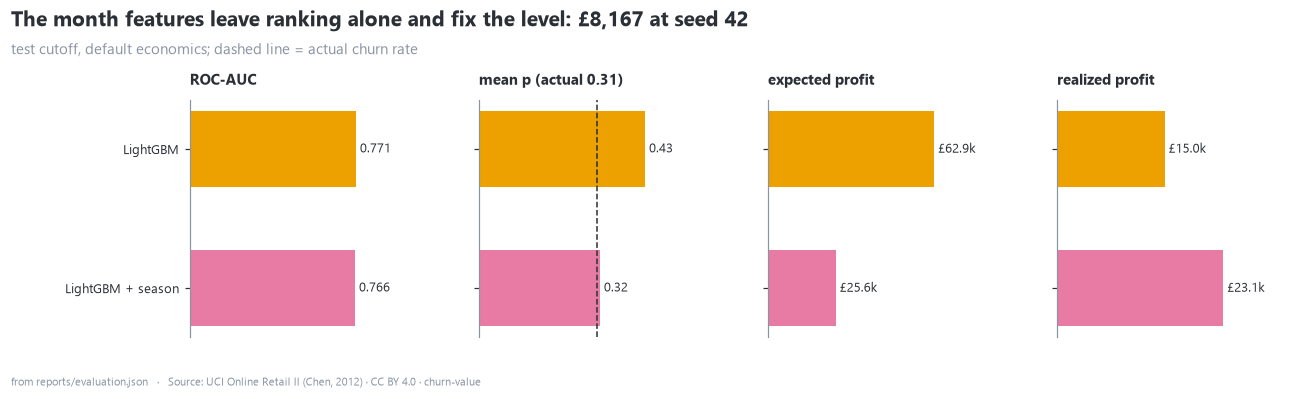

In [2]:
models = report["models"]
policies = {r["policy"]: r for r in report["policies"]}
pair = ["lightgbm", "lightgbm_seasonal"]
panels = [
    ("ROC-AUC", {n: models[n]["metrics"]["roc_auc"]["value"] for n in pair}, "{:.3f}"),
    (
        "mean p (actual {:.2f})".format(S["test_churn_rate"]),
        {n: models[n]["mean_p"] for n in pair},
        "{:.2f}",
    ),
    ("expected profit", {n: policies[n]["expected_profit"] for n in pair}, "£"),
    ("realized profit", {n: policies[n]["realized_profit"] for n in pair}, "£"),
]
fig, axes = plt.subplots(1, 4, figsize=(13, 2.8), sharey=True)
for ax, (title, values, fmt) in zip(axes, panels, strict=True):
    ys = np.arange(len(pair))[::-1]
    ax.barh(ys, [values[n] for n in pair], color=[MODEL_COLORS[n] for n in pair], height=0.55)
    for yv, n in zip(ys, pair, strict=True):
        text = style.gbp(values[n]) if fmt == "£" else fmt.format(values[n])
        ax.text(values[n], yv, f" {text}", va="center", fontsize=8.5, color=INK)
    ax.set_title(title, fontsize=9.5)
    ax.grid(axis="y", visible=False)
    ax.set_xticks([])
    ax.spines["bottom"].set_visible(False)
    ax.set_xlim(0, max(values.values()) * 1.45)
axes[0].set_yticks(np.arange(len(pair))[::-1], [MODEL_LABELS[n] for n in pair])
axes[1].axvline(S["test_churn_rate"], color=INK, lw=1, ls="--")
S["month_features"] = {
    n: {
        "roc_auc": panels[0][1][n],
        "mean_p": panels[1][1][n],
        "expected_profit": panels[2][1][n],
        "realized_profit": panels[3][1][n],
    }
    for n in pair
}
gain = policies["lightgbm_seasonal"]["realized_profit"] - policies["lightgbm"]["realized_profit"]
style.headline(
    fig,
    f"The month features leave ranking alone and fix the level: {style.gbp(gain)} at seed 42",
    "test cutoff, default economics; dashed line = actual churn rate",
)
style.add_source(fig, "from reports/evaluation.json")
save(fig, "month_features")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">A2 · A censored feature</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">`bought_same_window_last_year` is worth nothing measurable</span></div>

Stage 08 found that `bought_same_window_last_year` is 0 for everyone at the first three
training cutoffs, because the "same window last year" falls before the data begin, and only
partly observed at the next three. The model therefore learns from a flag that means "no data"
at some cutoffs and "did not buy" at others. Dropping it and refitting with the same
hyper-parameters, six times with different seeds, **changes nothing measurable**: the average
realized profit is the same with and without it, and the seed moves each variant far more.
The feature neither helps nor, it seems, misleads; it stays, documented as a known limitation.

In [3]:
censored = snapshots.groupby("cutoff")["bought_same_window_last_year"].mean()
S["censored_share_by_cutoff"] = censored.loc[list(split.train)].to_dict()
without = replace(
    DEPLOYED,
    name="without_last_year_flag",
    features=tuple(f for f in DEPLOYED.features if f != "bought_same_window_last_year"),
)
SEEDS = [1, 2, 3, 4, 5, 42]
variants = {}
for seed in SEEDS:
    variants[f"deployed seed {seed}"] = score_variant(DEPLOYED, PARAMS, seed)
    variants[f"without flag seed {seed}"] = score_variant(without, PARAMS, seed)
results = judge(variants)
results["variant"] = [
    "deployed" if k.startswith("deployed") else "without flag" for k in results.index
]
results["seed"] = [int(k.rsplit(" ", 1)[1]) for k in results.index]
summary = results.groupby("variant")[
    ["realized_profit", "expected_profit", "mean_p", "roc_auc"]
].agg(["mean", "min", "max"])
S["flag_ablation"] = {
    variant: {
        "realized_mean": summary.loc[variant, ("realized_profit", "mean")],
        "realized_min": summary.loc[variant, ("realized_profit", "min")],
        "realized_max": summary.loc[variant, ("realized_profit", "max")],
    }
    for variant in summary.index
}
display(
    summary.style.format(
        "{:,.3f}", subset=[c for c in summary.columns if c[0] in ("mean_p", "roc_auc")]
    ).format("£{:,.0f}", subset=[c for c in summary.columns if "profit" in c[0]])
)

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">A3 · The seed</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">the headline number has a spread of its own</span></div>

LightGBM samples rows and columns at random, so the seed changes the fitted trees. Refitting the
deployed configuration with six seeds (the pipeline uses 42) shows how much of the headline is
luck of the draw: the realized profit moves by a few thousand pounds between seeds, the
expected profit moves with it, and the ranking barely changes. The pipeline's seed 42 lands at
the top of this spread; the fair summary is the range, which the model card quotes.

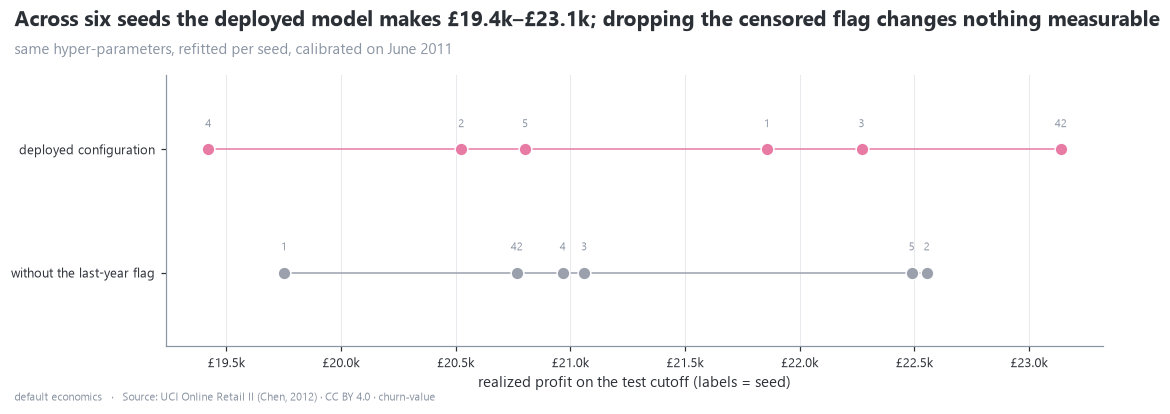

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.2))
for yv, (variant, color) in enumerate(
    [("without flag", RETAINED), ("deployed", MODEL_COLORS[DEPLOYED.name])]
):
    part = results[results["variant"] == variant]
    ax.scatter(
        part["realized_profit"],
        np.full(len(part), yv),
        s=70,
        color=color,
        zorder=3,
        edgecolor="white",
        linewidth=1,
    )
    for _, row in part.iterrows():
        ax.text(
            row["realized_profit"],
            yv + 0.18,
            str(int(row["seed"])),
            ha="center",
            fontsize=7.5,
            color=MUTED,
        )
    ax.plot(
        [part["realized_profit"].min(), part["realized_profit"].max()],
        [yv, yv],
        color=color,
        lw=1,
        zorder=2,
    )
ax.set_yticks([0, 1], ["without the last-year flag", "deployed configuration"])
ax.set_ylim(-0.6, 1.6)
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(lambda v, _: style.gbp(v))
ax.set_xlabel("realized profit on the test cutoff (labels = seed)")
deployed_runs = results[results["variant"] == "deployed"]
S["seed_range"] = [deployed_runs["realized_profit"].min(), deployed_runs["realized_profit"].max()]
S["seed_42"] = float(deployed_runs.loc[deployed_runs["seed"] == 42, "realized_profit"].iloc[0])
style.headline(
    fig,
    f"Across six seeds the deployed model makes {style.gbp(S['seed_range'][0])}–"
    f"{style.gbp(S['seed_range'][1])}; dropping the censored flag changes nothing measurable",
    "same hyper-parameters, refitted per seed, calibrated on June 2011",
)
style.add_source(fig, "default economics")
save(fig, "seeds")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">A4 · Fixes that fail</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">calibration tricks cannot replace knowing the month</span></div>

Instead of teaching the model the month, one could try to fix the probabilities after the fact.
Three standard ideas, applied to BG/NBD (the baseline that lost money) and, where it applies, to
the plain LightGBM:

- **same-season calibration** — calibrate on September 2010 instead of June 2011, so the
  calibration month matches the test month;
- **pooled calibration** — calibrate on every training cutoff and June together;
- **prior-shift correction** (Saerens et al., 2002) — re-estimate the churn rate on the test
  cutoff by EM and re-weight the probabilities, assuming only the class balance changed.

None works. Same-season calibration is fooled because BG/NBD's scores themselves drift between
cutoffs (stage 06); pooling mixes months with very different churn; and the EM estimate moves
the churn rate the *wrong way*, because the prior-shift assumption — that customers of each
class look the same in June and September — does not hold.

The last two rows remove the calibration step from LightGBM + season. Its raw scores are
already close to September's churn level: trained with a log-loss objective on cutoffs from
across the year, with the month as an input, the model is nearly calibrated on its own. The
June calibrator adjusts it slightly and adds a little profit here; the month features, not the
calibrator, do the heavy lifting.

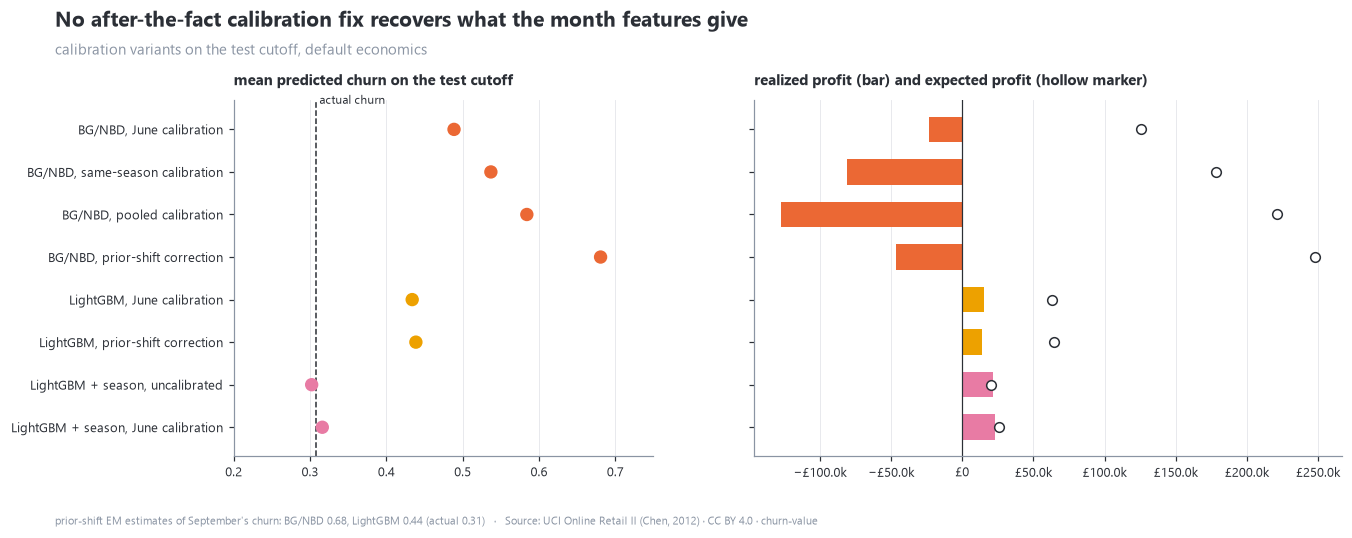

,mean_p,roc_auc,brier,contacted,expected_profit,realized_profit
"BG/NBD, June calibration",0.489,0.712,0.225,"1,565","£125,850","£-23,067"
"BG/NBD, same-season calibration",0.537,0.602,0.255,"1,876","£178,316","£-81,213"
"BG/NBD, pooled calibration",0.584,0.709,0.265,"1,918","£221,508","£-127,387"
"BG/NBD, prior-shift correction",0.681,0.712,0.336,"1,760","£248,076","£-46,455"
"LightGBM, June calibration",0.434,0.771,0.191,"1,294","£62,859","£14,972"
"LightGBM, prior-shift correction",0.439,0.771,0.193,"1,302","£64,536","£14,031"
"LightGBM + season, uncalibrated",0.302,0.766,0.178,"1,127","£20,375","£21,578"
"LightGBM + season, June calibration",0.316,0.766,0.176,993,"£25,621","£23,139"


In [5]:
bgnbd = BASELINE_SCORERS["bgnbd"]
sep_2010 = rows_at(snapshots, (pd.Timestamp("2010-09-10"),))
pooled = rows_at(snapshots, (*split.train, split.calibration))
june = select_calibrator(bgnbd(cal), y_cal, seed=SEED).transform(bgnbd(test))
fixes = {
    "BG/NBD, June calibration": june,
    "BG/NBD, same-season calibration": select_calibrator(
        bgnbd(sep_2010), sep_2010["churn"].to_numpy(float), seed=SEED
    ).transform(bgnbd(test)),
    "BG/NBD, pooled calibration": select_calibrator(
        bgnbd(pooled), pooled["churn"].to_numpy(float), seed=SEED
    ).transform(bgnbd(test)),
}
fixes["BG/NBD, prior-shift correction"], bg_prior = saerens_prior_shift(june, y_cal.mean())
plain = SUPERVISED["lightgbm"]
plain_p = score_variant(plain, training["lightgbm"]["params"], SEED)
fixes["LightGBM, June calibration"] = plain_p
fixes["LightGBM, prior-shift correction"], lgb_prior = saerens_prior_shift(plain_p, y_cal.mean())
deployed_estimator = fit_estimator(DEPLOYED, PARAMS, train, SEED)
fixes["LightGBM + season, uncalibrated"] = predict_churn(deployed_estimator, test, DEPLOYED)
fixes["LightGBM + season, June calibration"] = variants[f"deployed seed {SEED}"]
fix_table = judge(fixes)
S["fixes"] = fix_table.to_dict("index")
S["saerens_prior_estimates"] = {"bgnbd": bg_prior, "lightgbm": lgb_prior}

fig, axes = plt.subplots(
    1, 2, figsize=(13, 4.2), sharey=True, gridspec_kw={"width_ratios": [1, 1.4]}
)
ys = np.arange(len(fix_table))[::-1]
colors = [
    MODEL_COLORS["bgnbd"]
    if k.startswith("BG")
    else MODEL_COLORS["lightgbm_seasonal"]
    if "season" in k
    else MODEL_COLORS["lightgbm"]
    for k in fix_table.index
]
axes[0].scatter(fix_table["mean_p"], ys, color=colors, s=60, zorder=3)
axes[0].axvline(S["test_churn_rate"], color=INK, lw=1, ls="--")
axes[0].text(S["test_churn_rate"], len(ys) - 0.4, " actual churn", fontsize=8, color=INK)
axes[0].set_title("mean predicted churn on the test cutoff", fontsize=9.5)
axes[0].set_xlim(0.2, 0.75)
axes[1].barh(ys, fix_table["realized_profit"], color=colors, height=0.6)
axes[1].scatter(fix_table["expected_profit"], ys, facecolor="white", edgecolor=INK, s=40, zorder=3)
axes[1].axvline(0, color=INK, lw=0.8)
axes[1].set_title("realized profit (bar) and expected profit (hollow marker)", fontsize=9.5)
axes[1].xaxis.set_major_formatter(lambda v, _: style.gbp(v))
axes[0].set_yticks(ys, fix_table.index)
for ax in axes:
    ax.grid(axis="y", visible=False)
style.headline(
    fig,
    "No after-the-fact calibration fix recovers what the month features give",
    "calibration variants on the test cutoff, default economics",
)
style.add_source(
    fig,
    f"prior-shift EM estimates of September's churn: BG/NBD {bg_prior:.2f}, "
    f"LightGBM {lgb_prior:.2f} (actual {S['test_churn_rate']:.2f})",
)
save(fig, "fixes")
plt.show()
display(
    fix_table.style.format(
        {
            "mean_p": "{:.3f}",
            "roc_auc": "{:.3f}",
            "brier": "{:.3f}",
            "contacted": "{:,.0f}",
            "expected_profit": "£{:,.0f}",
            "realized_profit": "£{:,.0f}",
        }
    )
)

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">✓ · Summary and hand-off</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">11 → model card, web app</span></div>

**Produced** — `reports/results/11_summary.json` and the figures `11_month_features`,
`11_seeds`, `11_fixes`.

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #B7791F;background:rgba(183,121,31,0.12);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#B7791F">Key finding</span><ul style="margin:6px 0 0 18px;padding:0"><li>The month features are what turns a good ranking into trustworthy money: same ROC-AUC, a probability level that matches September, and an expected profit close to the realized one.</li><li>The censored last-year flag makes no measurable difference, while the random seed moves the realized profit by several thousand pounds: the headline is a range, not a point.</li><li>Calibration after the fact does not substitute for the month: same-season and pooled calibration and the prior-shift correction all leave BG/NBD losing money, and the prior-shift EM moves September's churn estimate the wrong way. With the month as an input, the model is nearly calibrated even before the calibrator.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#4A3AA7">Decision taken here</span><ul style="margin:6px 0 0 18px;padding:0"><li>Keep the deployed configuration, the flag included, and report the seed range alongside the headline in the model card and on the site.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #3B5B8C;background:rgba(59,91,140,0.10);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#3B5B8C">Left for a later stage</span><ul style="margin:6px 0 0 18px;padding:0"><li>A cleaner flag (missing when the last-year window is not observed) and seed averaging are possible refinements; neither changes the conclusions above.</li><li>Plan 3 — the web app, built on the artifacts these stages produced.</li></ul></div>

In [6]:
S.write(RESULTS)

WindowsPath('reports/results/11_summary.json')